# 📘 Suite du TP – Analyse des performances d'étudiants

🎯 **Objectif :** Approfondir la préparation du dataset pour une régression linéaire multiple en appliquant la standardisation, la réduction de dimension et la suppression des variables corrélées.

## 📦 Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Charger les fichiers X et y sauvegardés dans le TP précédent
X = pd.read_csv('X_students.csv')
y = pd.read_csv('y_students.csv')

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("\nColonnes de X :")
print(X.columns.tolist())
print("\nAperçu de X :")
X.head()

Dimensions de X : (1000, 13)
Dimensions de y : (1000, 1)

Colonnes de X :
['gender', "parent_edu_associate's degree", "parent_edu_bachelor's degree", 'parent_edu_high school', "parent_edu_master's degree", 'parent_edu_some college', 'parent_edu_some high school', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', 'lunch_standard', 'test preparation course_none']

Aperçu de X :


,gender,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,test preparation course_none
0,0,0,1,0,0,0,0,1,0,0,0,1,1
1,0,0,0,0,0,1,0,0,1,0,0,1,0
2,0,0,0,0,1,0,0,1,0,0,0,1,1
3,1,1,0,0,0,0,0,0,0,0,0,0,1
4,1,0,0,0,0,1,0,0,1,0,0,1,1


## 🔄 7. Normalisation et standardisation

**0** Comprendre la notion de normalisation et de standardisation 

**21.** Standardisez toutes les colonnes numériques de `X` (moyenne 0, écart-type 1) à l'aide de `StandardScaler`.

**22.** Comparez les résultats avec une normalisation min-max (`MinMaxScaler`).

### Comprendre la normalisation et la standardisation

- **Standardisation (StandardScaler)** : Transforme chaque variable pour qu'elle ait une **moyenne de 0** et un **écart-type de 1**. Formule : `z = (x - μ) / σ`. Utile quand les données suivent une distribution normale.

- **Normalisation Min-Max (MinMaxScaler)** : Redimensionne chaque variable dans l'intervalle **[0, 1]**. Formule : `x' = (x - x_min) / (x_max - x_min)`. Utile quand on veut des valeurs bornées.

In [2]:
# Question 21 : Standardisation avec StandardScaler (moyenne 0, écart-type 1)

scaler_standard = StandardScaler()
X_standardized = pd.DataFrame(
    scaler_standard.fit_transform(X),
    columns=X.columns
)

print("=== Résultats de la Standardisation (StandardScaler) ===")
print("\nMoyenne de chaque colonne (devrait être ≈ 0) :")
print(X_standardized.mean().round(6))
print("\nÉcart-type de chaque colonne (devrait être ≈ 1) :")
print(X_standardized.std().round(6))
print("\nAperçu des données standardisées :")
X_standardized.head()

=== Résultats de la Standardisation (StandardScaler) ===

Moyenne de chaque colonne (devrait être ≈ 0) :
gender                           0.0
parent_edu_associate's degree   -0.0
parent_edu_bachelor's degree     0.0
parent_edu_high school          -0.0
parent_edu_master's degree      -0.0
parent_edu_some college          0.0
parent_edu_some high school     -0.0
race/ethnicity_group B           0.0
race/ethnicity_group C           0.0
race/ethnicity_group D          -0.0
race/ethnicity_group E          -0.0
lunch_standard                  -0.0
test preparation course_none     0.0
dtype: float64

Écart-type de chaque colonne (devrait être ≈ 1) :
gender                           1.0005
parent_edu_associate's degree    1.0005
parent_edu_bachelor's degree     1.0005
parent_edu_high school           1.0005
parent_edu_master's degree       1.0005
parent_edu_some college          1.0005
parent_edu_some high school      1.0005
race/ethnicity_group B           1.0005
race/ethnicity_group C      

,gender,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,test preparation course_none
0,-0.964625,-0.534179,2.733967,-0.493742,-0.250398,-0.540361,-0.466933,2.064742,-0.684419,-0.59583,-0.403473,0.741881,0.746748
1,-0.964625,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.484322,1.461094,-0.59583,-0.403473,0.741881,-1.339140
2,-0.964625,-0.534179,-0.365769,-0.493742,3.993639,-0.540361,-0.466933,2.064742,-0.684419,-0.59583,-0.403473,0.741881,0.746748
3,1.036672,1.872032,-0.365769,-0.493742,-0.250398,-0.540361,-0.466933,-0.484322,-0.684419,-0.59583,-0.403473,-1.347925,0.746748
4,1.036672,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.484322,1.461094,-0.59583,-0.403473,0.741881,0.746748


In [3]:
# Question 22 : Normalisation Min-Max avec MinMaxScaler

scaler_minmax = MinMaxScaler()
X_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(X),
    columns=X.columns
)

print("=== Résultats de la Normalisation Min-Max (MinMaxScaler) ===")
print("\nMin de chaque colonne (devrait être 0) :")
print(X_normalized.min().round(6))
print("\nMax de chaque colonne (devrait être 1) :")
print(X_normalized.max().round(6))
print("\nAperçu des données normalisées :")
X_normalized.head()

=== Résultats de la Normalisation Min-Max (MinMaxScaler) ===

Min de chaque colonne (devrait être 0) :
gender                           0.0
parent_edu_associate's degree    0.0
parent_edu_bachelor's degree     0.0
parent_edu_high school           0.0
parent_edu_master's degree       0.0
parent_edu_some college          0.0
parent_edu_some high school      0.0
race/ethnicity_group B           0.0
race/ethnicity_group C           0.0
race/ethnicity_group D           0.0
race/ethnicity_group E           0.0
lunch_standard                   0.0
test preparation course_none     0.0
dtype: float64

Max de chaque colonne (devrait être 1) :
gender                           1.0
parent_edu_associate's degree    1.0
parent_edu_bachelor's degree     1.0
parent_edu_high school           1.0
parent_edu_master's degree       1.0
parent_edu_some college          1.0
parent_edu_some high school      1.0
race/ethnicity_group B           1.0
race/ethnicity_group C           1.0
race/ethnicity_group D    

,gender,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,test preparation course_none
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


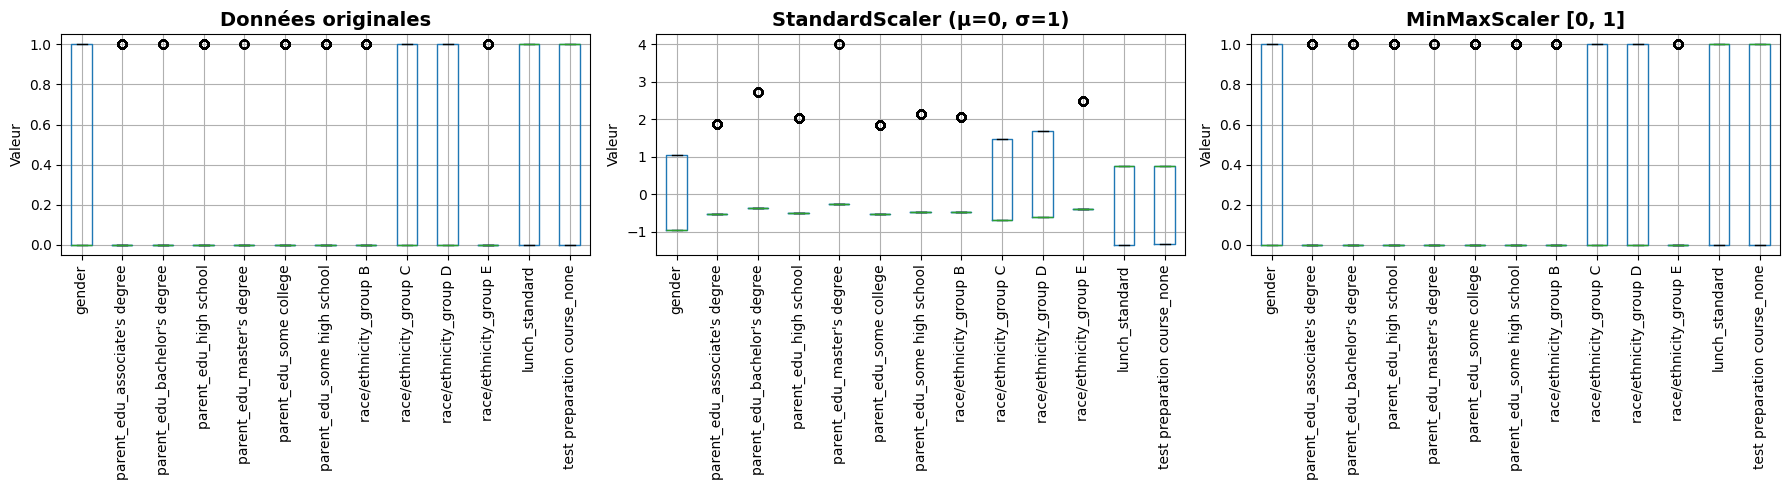


📊 Comparaison des statistiques :
                               Original_mean  Original_std  Standard_mean  \
gender                                 0.482      0.499926            0.0   
parent_edu_associate's degree          0.222      0.415799           -0.0   
parent_edu_bachelor's degree           0.118      0.322770            0.0   
parent_edu_high school                 0.196      0.397167           -0.0   
parent_edu_master's degree             0.059      0.235743           -0.0   
parent_edu_some college                0.226      0.418448            0.0   
parent_edu_some high school            0.179      0.383544           -0.0   
race/ethnicity_group B                 0.190      0.392497            0.0   
race/ethnicity_group C                 0.319      0.466322            0.0   
race/ethnicity_group D                 0.262      0.439943           -0.0   
race/ethnicity_group E                 0.140      0.347161           -0.0   
lunch_standard                         0.6

In [4]:
# Comparaison visuelle entre StandardScaler et MinMaxScaler

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Données originales
axes[0].set_title('Données originales', fontsize=14, fontweight='bold')
X.boxplot(ax=axes[0], rot=90)
axes[0].set_ylabel('Valeur')

# StandardScaler
axes[1].set_title('StandardScaler (μ=0, σ=1)', fontsize=14, fontweight='bold')
X_standardized.boxplot(ax=axes[1], rot=90)
axes[1].set_ylabel('Valeur')

# MinMaxScaler
axes[2].set_title('MinMaxScaler [0, 1]', fontsize=14, fontweight='bold')
X_normalized.boxplot(ax=axes[2], rot=90)
axes[2].set_ylabel('Valeur')

plt.tight_layout()
plt.show()

print("\n📊 Comparaison des statistiques :")
comparison = pd.DataFrame({
    'Original_mean': X.mean(),
    'Original_std': X.std(),
    'Standard_mean': X_standardized.mean().round(6),
    'Standard_std': X_standardized.std().round(4),
    'MinMax_min': X_normalized.min(),
    'MinMax_max': X_normalized.max()
})
print(comparison)

## 🔁 8. Suppression des variables trop corrélées

**0.** Comprendre la notion de corrélation linéaire. 

**23.** Calculez la **matrice de corrélation** entre les variables explicatives (`X`).

**24.** Supprimez les variables dont la corrélation dépasse un seuil (ex : > 0.9).

**25.** Réaffichez la heatmap pour valider.

### Comprendre la corrélation linéaire

La **corrélation linéaire** (coefficient de Pearson) mesure la force et la direction de la relation linéaire entre deux variables :
- **r = 1** : corrélation positive parfaite
- **r = -1** : corrélation négative parfaite  
- **r = 0** : aucune corrélation linéaire

Quand deux variables sont **très corrélées** (|r| > 0.9), elles apportent une information redondante. On peut alors en supprimer une pour éviter la **multicolinéarité**, qui peut nuire aux modèles de régression.

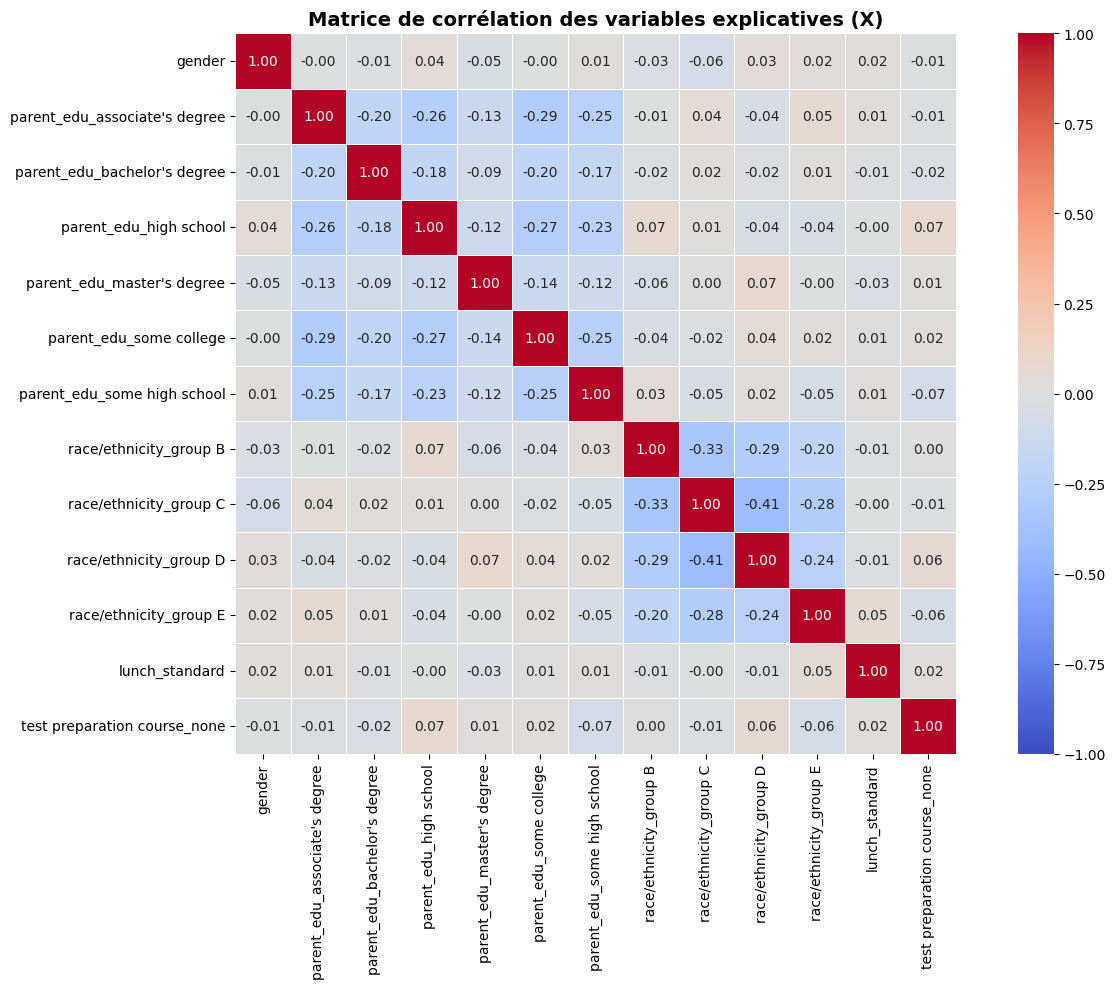


Matrice de corrélation :
                               gender  parent_edu_associate's degree  \
gender                          1.000                         -0.005   
parent_edu_associate's degree  -0.005                          1.000   
parent_edu_bachelor's degree   -0.012                         -0.195   
parent_edu_high school          0.038                         -0.264   
parent_edu_master's degree     -0.046                         -0.134   
parent_edu_some college        -0.004                         -0.289   
parent_edu_some high school     0.009                         -0.249   
race/ethnicity_group B         -0.028                         -0.007   
race/ethnicity_group C         -0.063                          0.037   
race/ethnicity_group D          0.031                         -0.045   
race/ethnicity_group E          0.020                          0.055   
lunch_standard                  0.021                          0.009   
test preparation course_none   -0.006 

In [5]:
# Question 23 : Calcul de la matrice de corrélation

corr_matrix = X.corr()

# Affichage de la heatmap de corrélation
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Matrice de corrélation des variables explicatives (X)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMatrice de corrélation :")
print(corr_matrix.round(3))

In [6]:
# Question 24 : Suppression des variables avec corrélation > 0.9

seuil = 0.9

# Prendre la valeur absolue de la matrice de corrélation
corr_abs = corr_matrix.abs()

# Garder uniquement le triangle supérieur (éviter les doublons et la diagonale)
upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# Identifier les colonnes ayant une corrélation > seuil
cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > seuil)]

print(f"Seuil de corrélation : {seuil}")
print(f"\nVariables à supprimer : {cols_to_drop}")

if len(cols_to_drop) > 0:
    # Afficher les paires de variables trop corrélées
    print("\nPaires de variables avec corrélation > seuil :")
    for col in upper_triangle.columns:
        for idx in upper_triangle.index:
            val = upper_triangle.loc[idx, col]
            if pd.notna(val) and val > seuil:
                print(f"  {idx} <-> {col} : {val:.4f}")
    
    # Supprimer les colonnes
    X_reduced = X.drop(columns=cols_to_drop)
    print(f"\nDimensions avant suppression : {X.shape}")
    print(f"Dimensions après suppression : {X_reduced.shape}")
    print(f"\nColonnes restantes : {X_reduced.columns.tolist()}")
else:
    X_reduced = X.copy()
    print("\n✅ Aucune variable ne dépasse le seuil de corrélation.")
    print("Toutes les variables sont conservées.")
    print(f"Dimensions de X : {X_reduced.shape}")

Seuil de corrélation : 0.9

Variables à supprimer : []

✅ Aucune variable ne dépasse le seuil de corrélation.
Toutes les variables sont conservées.
Dimensions de X : (1000, 13)


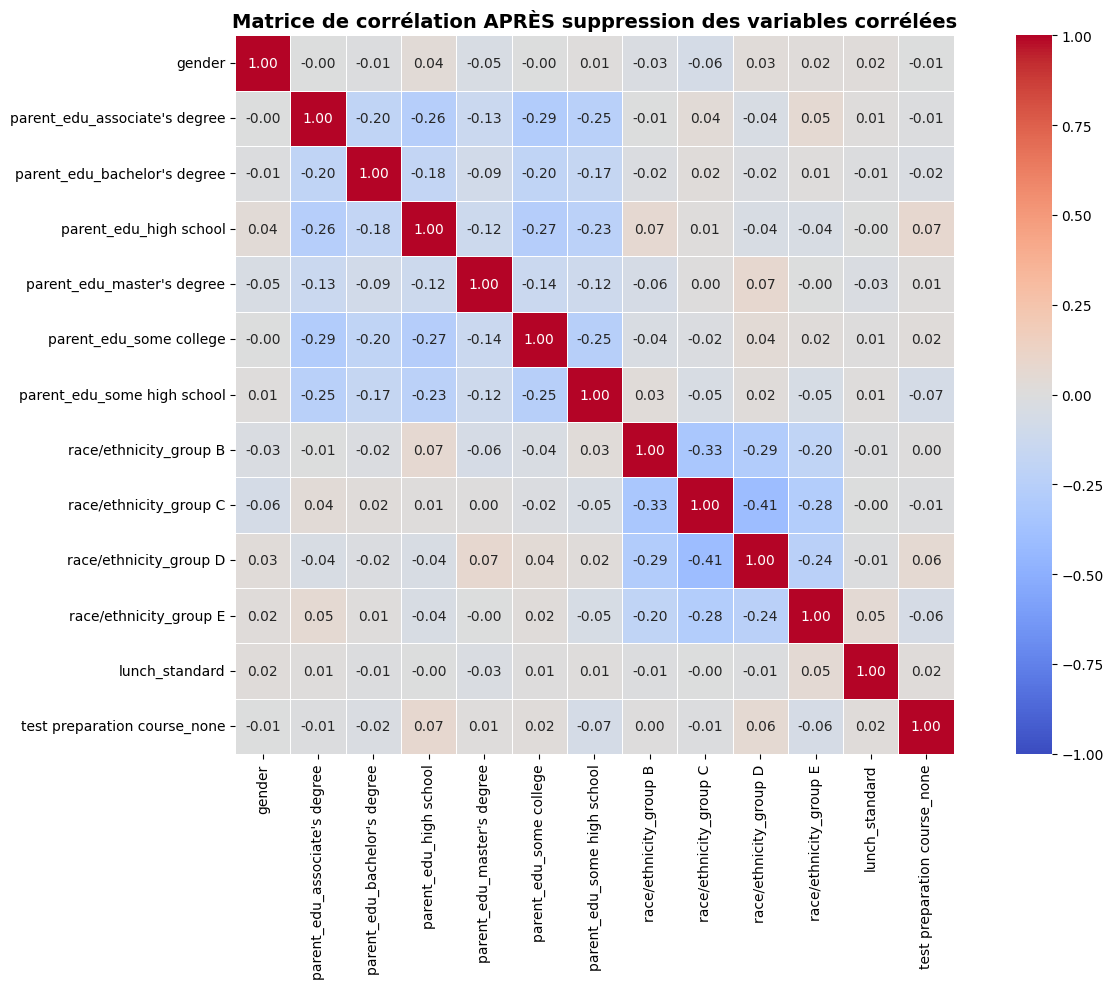


✅ Corrélation maximale restante (hors diagonale) : 0.4078
   Toutes les corrélations sont en dessous du seuil de 0.9.


In [7]:
# Question 25 : Réafficher la heatmap après suppression pour validation

corr_matrix_reduced = X_reduced.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix_reduced,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Matrice de corrélation APRÈS suppression des variables corrélées', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Vérification : aucune corrélation > seuil ne reste
corr_abs_reduced = corr_matrix_reduced.abs()
upper_reduced = corr_abs_reduced.where(
    np.triu(np.ones(corr_abs_reduced.shape), k=1).astype(bool)
)
max_corr = upper_reduced.max().max()
print(f"\n✅ Corrélation maximale restante (hors diagonale) : {max_corr:.4f}")
if max_corr <= seuil:
    print(f"   Toutes les corrélations sont en dessous du seuil de {seuil}.")

## 🧬 9. Réduction de dimension (PCA)

**0.** Comprendre la notion de réduction de dimension. Essayer de comprendre PCA globalement

**26.** Appliquez une **PCA** sur les données standardisées.

**27.** Affichez la variance expliquée par chaque composante.

**28.** Tracez un nuage de points 2D selon les 2 premières composantes.

### Comprendre la réduction de dimension et PCA

La **réduction de dimension** consiste à diminuer le nombre de variables tout en conservant le maximum d'information.

**PCA (Analyse en Composantes Principales)** :
- Transforme les variables originales en nouvelles variables **non corrélées** appelées **composantes principales**.
- Les composantes sont ordonnées : la 1ère capture le plus de variance, la 2ème le plus de variance restante, etc.
- Permet de réduire la dimensionnalité en ne gardant que les composantes les plus informatives.
- **Important** : PCA doit être appliquée sur des données **standardisées** pour éviter que les variables à grande échelle dominent.

In [8]:
# Question 26 : Appliquer PCA sur les données standardisées

# Standardiser X_reduced avant PCA
scaler_pca = StandardScaler()
X_std_for_pca = scaler_pca.fit_transform(X_reduced)

# Appliquer PCA avec toutes les composantes
pca = PCA()
X_pca = pca.fit_transform(X_std_for_pca)

print(f"Nombre de composantes principales : {pca.n_components_}")
print(f"Dimensions des données après PCA : {X_pca.shape}")
print(f"\nAperçu des 5 premières lignes (3 premières composantes) :")
pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print(pca_df.iloc[:5, :3])

Nombre de composantes principales : 13
Dimensions des données après PCA : (1000, 13)

Aperçu des 5 premières lignes (3 premières composantes) :
        PC1       PC2       PC3
0  0.158922  1.457373  0.319536
1  1.012931 -1.498133 -0.799476
2 -0.493055  0.921381 -0.238534
3  0.455541 -0.171076  1.033999
4  0.620157 -1.303942 -1.142518


Variance expliquée par chaque composante :
  PC1 : 0.1129 (11.29%)  |  Cumulée : 0.1129 (11.29%)
  PC2 : 0.1055 (10.55%)  |  Cumulée : 0.2184 (21.84%)
  PC3 : 0.1015 (10.15%)  |  Cumulée : 0.3200 (32.00%)
  PC4 : 0.0977 (9.77%)  |  Cumulée : 0.4176 (41.76%)
  PC5 : 0.0951 (9.51%)  |  Cumulée : 0.5127 (51.27%)
  PC6 : 0.0899 (8.99%)  |  Cumulée : 0.6026 (60.26%)
  PC7 : 0.0867 (8.67%)  |  Cumulée : 0.6894 (68.94%)
  PC8 : 0.0825 (8.25%)  |  Cumulée : 0.7719 (77.19%)
  PC9 : 0.0766 (7.66%)  |  Cumulée : 0.8484 (84.84%)
  PC10 : 0.0723 (7.23%)  |  Cumulée : 0.9207 (92.07%)
  PC11 : 0.0703 (7.03%)  |  Cumulée : 0.9910 (99.10%)
  PC12 : 0.0090 (0.90%)  |  Cumulée : 1.0000 (100.00%)
  PC13 : 0.0000 (0.00%)  |  Cumulée : 1.0000 (100.00%)


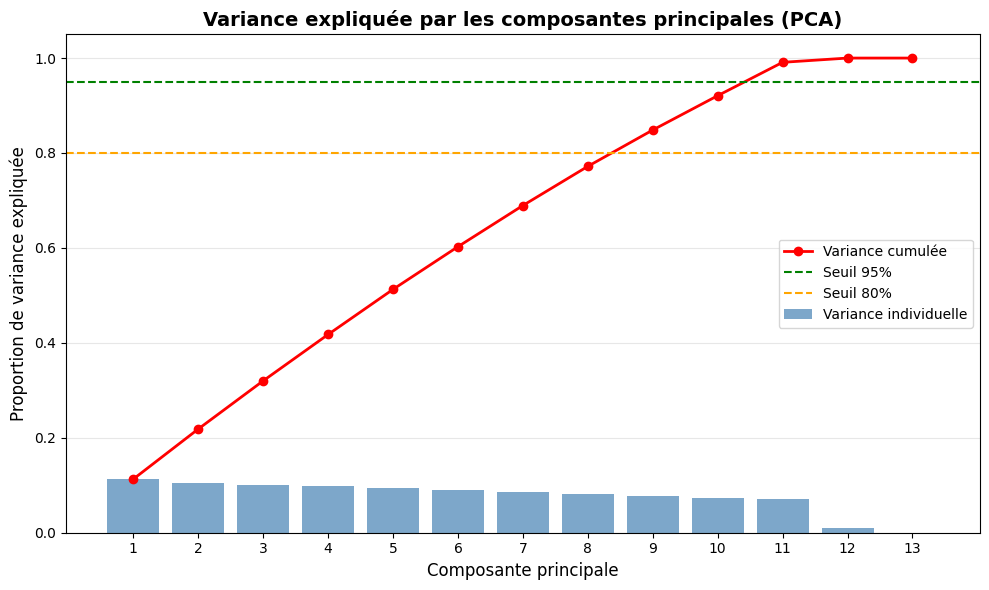


📌 Nombre de composantes pour 80% de la variance : 9
📌 Nombre de composantes pour 95% de la variance : 11


In [9]:
# Question 27 : Variance expliquée par chaque composante

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Variance expliquée par chaque composante :")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1} : {var:.4f} ({var*100:.2f}%)  |  Cumulée : {cum:.4f} ({cum*100:.2f}%)")

# Graphique de la variance expliquée
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = range(1, len(explained_var) + 1)
ax.bar(x_vals, explained_var, alpha=0.7, label='Variance individuelle', color='steelblue')
ax.plot(x_vals, cumulative_var, 'ro-', label='Variance cumulée', linewidth=2)
ax.axhline(y=0.95, color='green', linestyle='--', label='Seuil 95%')
ax.axhline(y=0.80, color='orange', linestyle='--', label='Seuil 80%')

ax.set_xlabel('Composante principale', fontsize=12)
ax.set_ylabel('Proportion de variance expliquée', fontsize=12)
ax.set_title('Variance expliquée par les composantes principales (PCA)', fontsize=14, fontweight='bold')
ax.set_xticks(list(x_vals))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Nombre de composantes pour 95% de la variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"\n📌 Nombre de composantes pour 80% de la variance : {n_80}")
print(f"📌 Nombre de composantes pour 95% de la variance : {n_95}")

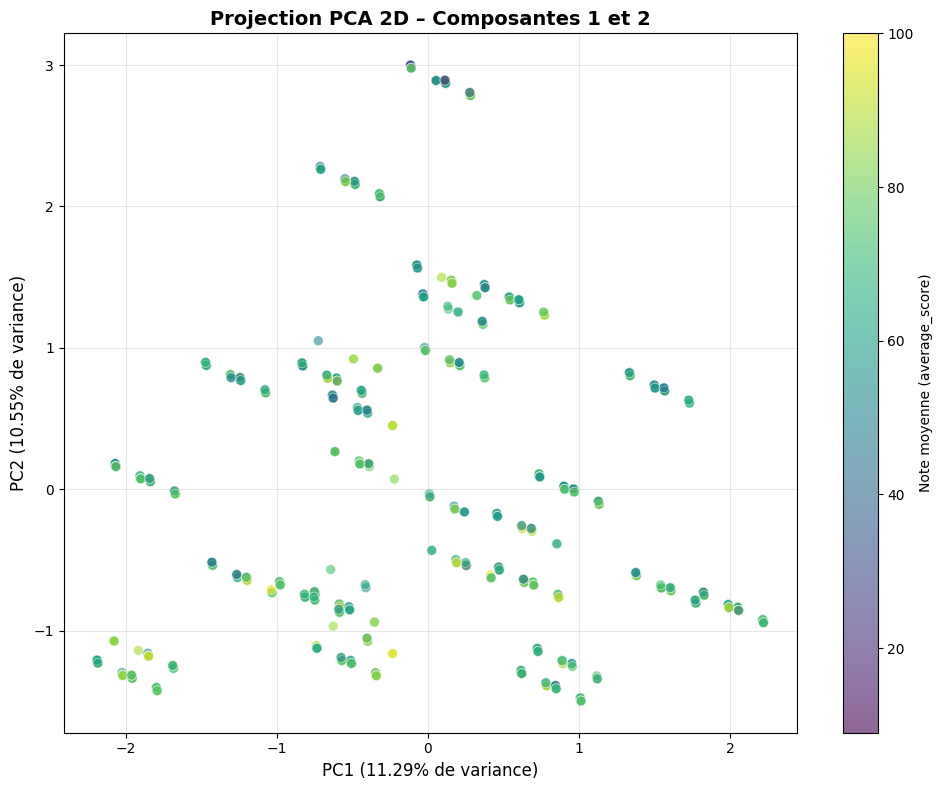


📊 Les 2 premières composantes expliquent 21.84% de la variance totale.


In [10]:
# Question 28 : Nuage de points 2D selon les 2 premières composantes

plt.figure(figsize=(10, 8))

# Utiliser y (average_score) comme couleur pour voir si la PCA sépare bien les étudiants
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y.values.ravel(),
    cmap='viridis',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    s=50
)

plt.colorbar(scatter, label='Note moyenne (average_score)')
plt.xlabel(f'PC1 ({explained_var[0]*100:.2f}% de variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]*100:.2f}% de variance)', fontsize=12)
plt.title('Projection PCA 2D – Composantes 1 et 2', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Les 2 premières composantes expliquent {cumulative_var[1]*100:.2f}% de la variance totale.")